<a href="https://colab.research.google.com/github/enilt/langgraph-alura/blob/main/Aula_06_OrquestMultiAg_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 06 — Orquestração de Multiagentes (Essay Writer) com LangGraph + Groq

Aqui montamos um fluxo com **vários agentes/nós** cooperando para escrever uma redação:
`planner → research_plan → generate → reflect → research_critique → generate …` (com ciclo de revisões).

> Convenções mantidas (agora com **Groq**):
> - Modelo **Groq** `openai/gpt-oss-120b` via `langchain-groq` (com `reasoning_effort` explícito)
> - Chaves automáticas (`GROQ_API_KEY` + `TAVILY_API_KEY`) via Secrets do Colab / `.env` / coladas
> - Busca com o cliente **Tavily** (`tavily-python`)
> - Persistência com **`SqliteSaver`** + `memory.setup()`

## 1. Instalação das dependências

In [1]:
%pip install -U langgraph langchain langchain-groq langchain-tavily tavily-python python-dotenv aiosqlite langgraph-checkpoint-sqlite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.4/163.4 kB 11.4 MB/s eta 0:00:00
  Attempting uninstall: python-dotenv
    Found existing installation: python-dotenv 1.2.3
    Uninstalling python-dotenv-1.2.3:
      Successfully uninstalled python-dotenv-1.2.3
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.11
    Uninstalling langgraph-1.2.11:
      Successfully uninstalled langgraph-1.2.11
  Attempting uninstall: langchain
    Found existing installation: langchain 1.4.0
    Uninstalling langchain-1.4.0:
      Successfully uninstalled langchain-1.4.0


## 2. Importações

In [2]:
import os
import sqlite3
import operator
from typing import TypedDict, Annotated, List

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.sqlite import SqliteSaver

from langchain_core.messages import (
    AnyMessage, SystemMessage, HumanMessage, AIMessage, ChatMessage
)

from langchain_groq import ChatGroq
from tavily import TavilyClient
from pydantic import BaseModel

## 3. Chaves de API (sem digitar toda vez)

Escolha **uma** opção (todas automáticas):
1. **Colar** os valores nas variáveis abaixo.
2. **Secrets do Colab** (🔑): crie `GROQ_API_KEY` e `TAVILY_API_KEY` com "Notebook access" ativado; deixe as variáveis vazias.
3. **Arquivo `.env`** (local).

A célula mostra um diagnóstico por chave, dizendo exatamente o que faltou caso algo dê errado.

In [3]:
# Cole aqui se quiser (opcional). Vazio = busca automatica nos Secrets do Colab / .env
GROQ_API_KEY = ""     # ex: "gsk_..."
TAVILY_API_KEY = ""   # ex: "tvly-..."


def resolver_chave(nome, valor_manual):
    if valor_manual:
        return valor_manual.strip()
    try:
        from google.colab import userdata
        try:
            v = userdata.get(nome)
            if v and v.strip():
                print(f"[OK] '{nome}' encontrada nos Secrets do Colab.")
                return v.strip()
            else:
                print(f"[VAZIO] '{nome}' existe nos Secrets do Colab, mas está vazia.")
        except userdata.SecretNotFoundError:
            print(f"[NAO EXISTE] '{nome}' não encontrada nos Secrets. Confira o NOME exato '{nome}'.")
        except userdata.NotebookAccessError:
            print(f"[SEM ACESSO] '{nome}' existe, mas 'Notebook access' NÃO está ativado.")
        except Exception as e:
            print(f"[ERRO] ao ler '{nome}' do Colab: {type(e).__name__}: {e}")
    except ImportError:
        pass
    try:
        from dotenv import load_dotenv
        load_dotenv()
    except ImportError:
        pass
    v = os.getenv(nome)
    return v.strip() if v else None


print("--- Verificando chaves ---")
groq_key = resolver_chave("GROQ_API_KEY", GROQ_API_KEY)
tavily_key = resolver_chave("TAVILY_API_KEY", TAVILY_API_KEY)

faltando = [n for n, k in [("GROQ_API_KEY", groq_key), ("TAVILY_API_KEY", tavily_key)] if not k]
if faltando:
    raise ValueError(
        "Chaves ausentes: " + ", ".join(faltando) + ". Veja as mensagens acima. "
        "Cole na célula, use os Secrets do Colab (nome exato + Notebook access) ou o .env."
    )

os.environ["GROQ_API_KEY"] = groq_key
os.environ["TAVILY_API_KEY"] = tavily_key
print("Chaves carregadas com sucesso!")

--- Verificando chaves ---
[OK] 'GROQ_API_KEY' encontrada nos Secrets do Colab.
[OK] 'TAVILY_API_KEY' encontrada nos Secrets do Colab.
Chaves carregadas com sucesso!


## 4. Persistência (SqliteSaver)

`memory.setup()` cria as tabelas de checkpoint (sem isso o `graph.stream(...)` falha com `no such table: checkpoints`).

In [4]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)

try:
    memory.setup()
except Exception as e:
    print("Aviso ao preparar o SqliteSaver:", e)

## 5. Estado do agente

In [5]:
class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

## 6. Modelo (Groq)

In [6]:
# Convencao das aulas: Groq openai/gpt-oss-120b, com reasoning_effort explicito.
# max_retries: o cliente aguarda e tenta de novo automaticamente em caso de
# rate limit (429), respeitando o tempo pedido pela Groq.
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    reasoning_effort="low",
    max_retries=6,
)

## 7. Prompts dos agentes

In [7]:
PLAN_PROMPT = """Você é um escritor especialista com a tarefa de criar um esboço de alto nível para uma redação. \
Escreva esse esboço para o tópico fornecido pelo usuário. Apresente um plano da redação junto com quaisquer notas \
ou instruções relevantes para as seções."""

In [8]:
WRITER_PROMPT = """Você é um assistente de redação com a tarefa de escrever excelentes redações de 5 parágrafos. \
Gere a melhor redação possível para a solicitação do usuário e o esboço inicial. \
Se o usuário fornecer críticas, responda com uma versão revisada das suas tentativas anteriores. \
Utilize todas as informações abaixo conforme necessário:

------

{content}"""

In [9]:
REFLECTION_PROMPT = """Você é um professor corrigindo uma redação submetida. \
Gere uma crítica e recomendações para a submissão do usuário. \
Forneça recomendações detalhadas, incluindo pedidos sobre extensão, profundidade, estilo, etc."""

In [10]:
RESEARCH_PLAN_PROMPT = """Você é um pesquisador encarregado de fornecer informações que podem \
ser usadas ao escrever a seguinte redação. Gere uma lista de consultas de pesquisa que \
recolham quaisquer informações relevantes. Gere no máximo 3 consultas."""

In [11]:
RESEARCH_CRITIQUE_PROMPT = """Você é um pesquisador encarregado de fornecer informações que podem \
ser usadas ao fazer quaisquer revisões solicitadas (conforme descrito abaixo). \
Gere uma lista de consultas de pesquisa que recolham quaisquer informações relevantes. Gere no máximo 3 consultas."""

## 8. Schema de saída estruturada e cliente Tavily

`Queries` (Pydantic) define o formato da saída estruturada usada pelo modelo para gerar consultas de busca.

In [12]:
class Queries(BaseModel):
    queries: List[str]


# O gpt-oss-120b no Groq falha com "tool choice" forçado (structured output via
# function calling). Usamos o modo JSON, que é robusto, e instruímos o formato.
INSTRUCAO_JSON = (
    ' Responda APENAS com um objeto JSON válido no formato '
    '{"queries": ["consulta 1", "consulta 2", "consulta 3"]}, sem nenhum texto extra.'
)

gerador_de_queries = model.with_structured_output(Queries, method="json_mode")

In [13]:
tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

## 9. Nós do grafo (os agentes)

In [14]:
def plan_node(state: AgentState):
    messages = [
        SystemMessage(content=PLAN_PROMPT),
        HumanMessage(content=state['task'])
    ]
    response = model.invoke(messages)
    return {"plan": response.content}

In [15]:
def research_plan_node(state: AgentState):
    queries = gerador_de_queries.invoke([
        SystemMessage(content=RESEARCH_PLAN_PROMPT + INSTRUCAO_JSON),
        HumanMessage(content=state['task'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=1)
        for r in response['results']:
            # Trunca para economizar tokens (plano gratuito da Groq: 8000 TPM)
            content.append(r['content'][:800])
    return {"content": content}

In [16]:
def generation_node(state: AgentState):
    content = "\n\n".join(state['content'] or [])
    user_message = HumanMessage(
        content=f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}")
    messages = [
        SystemMessage(content=WRITER_PROMPT.format(content=content)),
        user_message
    ]
    response = model.invoke(messages)
    return {
        "draft": response.content,
        "revision_number": state.get("revision_number", 1) + 1
    }

In [17]:
def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content=REFLECTION_PROMPT),
        HumanMessage(content=state['draft'])
    ]
    response = model.invoke(messages)
    return {"critique": response.content}

In [18]:
def research_critique_node(state: AgentState):
    queries = gerador_de_queries.invoke([
        SystemMessage(content=RESEARCH_CRITIQUE_PROMPT + INSTRUCAO_JSON),
        HumanMessage(content=state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query=q, max_results=1)
        for r in response['results']:
            content.append(r['content'][:800])
    return {"content": content}

In [19]:
def should_continue(state):
    if state["revision_number"] > state["max_revisions"]:
        return END
    return "reflect"

## 10. Montagem do grafo

In [20]:
builder = StateGraph(AgentState)

builder.add_node("planner", plan_node)
builder.add_node("generate", generation_node)
builder.add_node("reflect", reflection_node)
builder.add_node("research_plan", research_plan_node)
builder.add_node("research_critique", research_critique_node)

builder.set_entry_point("planner")

builder.add_conditional_edges(
    "generate",
    should_continue,
    {END: END, "reflect": "reflect"}
)

builder.add_edge("planner", "research_plan")
builder.add_edge("research_plan", "generate")
builder.add_edge("reflect", "research_critique")
builder.add_edge("research_critique", "generate")

graph = builder.compile(checkpointer=memory)

## 11. Visualização do grafo


--- Tentando gerar PNG do grafo via Mermaid ---


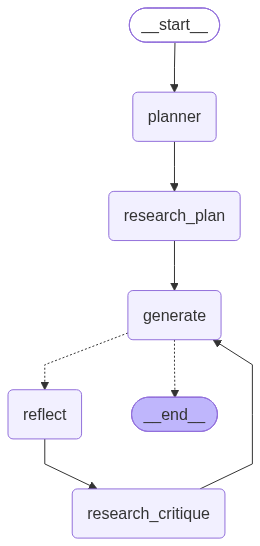

Grafo PNG gerado e exibido com sucesso!


In [21]:
from IPython.display import Image, display, Markdown

print("\n--- Tentando gerar PNG do grafo via Mermaid ---")
try:
    image_data = graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
    print("Grafo PNG gerado e exibido com sucesso!")
except Exception as e:
    print(f"\nErro ao tentar gerar o PNG do grafo: {e}")
    print("Tentando gerar apenas o código Mermaid (fallback)...")
    try:
        mermaid_code = graph.get_graph().draw_mermaid()
        print("\n--- Código Mermaid (cole em https://mermaid.live/) ---")
        print(mermaid_code)
    except Exception as e_mermaid:
        print(f"Erro ao gerar código Mermaid: {e_mermaid}")

## 12. Executando a orquestração

O grafo vai planejar, pesquisar, escrever, criticar e revisar até atingir `max_revisions`.

In [22]:
thread = {"configurable": {"thread_id": "1"}}
for s in graph.stream({
    'task': "Qual é a diferença entre o langchain e langsmith",
    "max_revisions": 1,      # menos revisões = menos chamadas (evita o limite de tokens/minuto)
    "revision_number": 1,
    "content": [],
}, thread):
    print(s)

{'planner': {'plan': '**Esboço de Redação – “Qual é a diferença entre LangChain e LangSmith?”**  \n\n---\n\n### 1. Introdução  \n- **Gancho**: Breve menção ao crescimento explosivo das aplicações de IA generativa e à necessidade de ferramentas que facilitem o desenvolvimento e a manutenção desses sistemas.  \n- **Contextualização**: Apresentar rapidamente o ecossistema da **LangChain** (framework para construção de cadeias de LLM) e da **LangSmith** (plataforma de observabilidade e gerenciamento de pipelines).  \n- **Tese**: Embora ambas pertençam ao mesmo “universo” de desenvolvimento com LLMs, LangChain e LangSmith atendem a propósitos distintos – a primeira foca na **criação** de fluxos de trabalho inteligentes, enquanto a segunda se concentra na **monitorização, depuração e otimização** desses fluxos em produção.  \n\n---\n\n### 2. Visão geral de cada ferramenta  \n\n#### 2.1. LangChain  \n- **Objetivo principal**: Simplificar a construção de aplicações que combinam LLMs com outras